Plotly is used as the new package that uses built in color modification


In [1]:
pip install plotly #New package used for the project> Plotly allowed for more advance color customization

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#New': Expected package name at the start of dependency specifier
    #New
    ^


In [2]:
#Importing tools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv("NHTS(in).csv") 

In [4]:
#This cell alows us to understand the column names, data types, and missing values.
df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14684 entries, 0 to 14683
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   household_id             14684 non-null  int64 
 1   census_division          14684 non-null  object
 2   census_region            14684 non-null  object
 3   driver_count             14684 non-null  int64 
 4   household_income         14684 non-null  object
 5   household_size           14684 non-null  int64 
 6   household_workers        14684 non-null  int64 
 7   home_type                14684 non-null  object
 8   household_location       14684 non-null  object
 9   number_adults_household  14684 non-null  int64 
 10  vehicles_per_household   14684 non-null  int64 
 11  travel_date              14684 non-null  int64 
 12  travel_day               14684 non-null  object
 13  urban                    14684 non-null  object
 14  vehicle_type             14684 non-nul

In [5]:
#Drop missing values
df = df.dropna()

In [6]:
#Filter data to the midwest region
midwest_df = df[df['census_region'] == 'Midwest']

In [7]:
#Creaing a copy of the data frame ti avoid assignment issues
midwest_df = df[df['census_region'] == 'Midwest'].copy()

#Creating income categories

def income_category(income):
    if pd.isna(income):
        return None

    if any(x in income for x in ["Less than", "$0", "$10,000", "$15,000", "$20,000", "$25,000", "$30,000", "$35,000", "$40,000", "$45,000"]):
        return "Low"
    
    elif any(x in income for x in ["$50,000", "$75,000", "$100,000", "$125,000"]):
        return "Middle"
    
    elif any(x in income for x in ["$150,000", "$175,000"]):
        return "High"
    
    return "Middle"

midwest_df['income_group'] = midwest_df['household_income'].apply(income_category)

#Print results
print(midwest_df['income_group'].value_counts())


income_group
Middle    145
High       69
Low        65
Name: count, dtype: int64


In [8]:
print(midwest_df['fuel_type'].value_counts().head(20))

fuel_type
Gas                                  237
Diesel                                25
Hybrid, gas/electric, non plug-in     14
Electric only                          3
Name: count, dtype: int64


In [9]:
#Fuel Category
def fuel_category(fuel):
    if pd.isna(fuel):
        return None
    
    fuel = str(fuel).lower()
    
    if fuel in ["gas", "gasoline", "diesel"]:
        return "Conventional"
    
    elif "hybrid" in fuel or "electric" in fuel:
        return "Alternative"
    
    else:
        return "Other"

midwest_df['fuel_category'] = midwest_df['fuel_type'].apply(fuel_category)

print(midwest_df['fuel_category'].value_counts())

fuel_category
Conventional    262
Alternative      17
Name: count, dtype: int64


Usage frequecny feature

Measuring the columns household_id, vehicle_type, and travel_date to apporximated how many times a household vehicle combination appears in the data set.

Note that fuel categories were simplified to 'Alternative and 'Conventional'

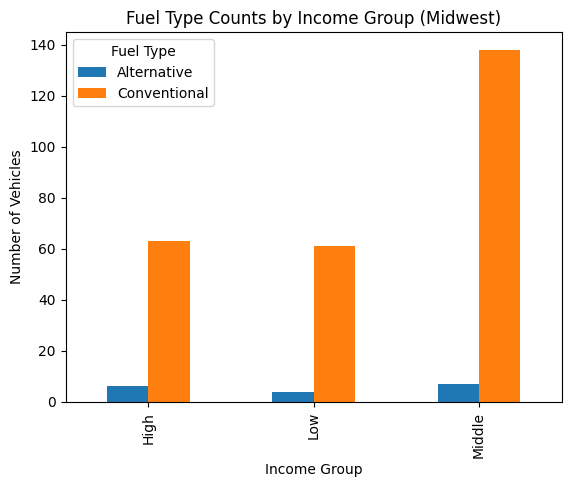

In [10]:
fuel_income_counts = midwest_df.groupby('income_group')['fuel_category'].value_counts().unstack()

fuel_income_counts.plot(kind='bar')

plt.title("Fuel Type Counts by Income Group (Midwest)")
plt.ylabel("Number of Vehicles")
plt.xlabel("Income Group")
plt.legend(title="Fuel Type")

plt.show()

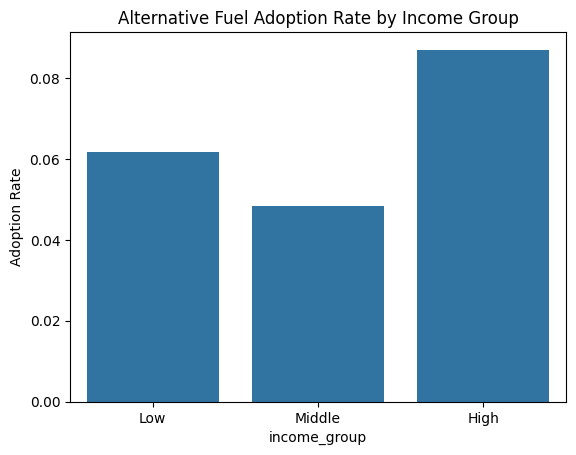

In [11]:
sns.barplot(
    data=midwest_df,
    x='income_group',
    y=midwest_df.groupby('income_group')['fuel_category'].transform(lambda x: (x == "Alternative").mean())
)

plt.title("Alternative Fuel Adoption Rate by Income Group")
plt.ylabel("Adoption Rate")
plt.show()

In [12]:
travel_counts = midwest_df.groupby('income_group')['travel_day'].value_counts(normalize=True).reset_index(name='proportion')

#This groups the dataset by income group and calculates the proportion of each travel day (e.g., Monday, Tuesday, etc.) within each group.
#Chat gpt was used to help write this line of code

In [18]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

fig = px.bar(
    travel_counts,
    x='income_group',
    y='proportion',
    color='travel_day',
    barmode='group',
    title="Travel Day Distribution by Income Group (Midwest)",
    
    # Blue/green color palette
    color_discrete_sequence=[
        "#1f77b4",  # blue
        "#2ca02c",  # green
        "#17becf",  # teal
        "#4daf4a",  # soft green
        "#377eb8",  # deeper blue
        "#66c2a5",  # light teal
        "#a6cee3"   # light blue
    ]
)

fig.update_layout(
    xaxis_title="Income Group",
    yaxis_title="Proportion",
    legend_title="Day of Week"
)



fig.update_xaxes(categoryorder='array', categoryarray=['Low','Middle','High'])

In [16]:
vehicle_counts = midwest_df.groupby(
    ['income_group', 'vehicle_type']
).size().reset_index(name='proportion')

In [17]:
import plotly.express as px

fig = px.bar(
    vehicle_counts,
    x='income_group',
    y='proportion',
    color='vehicle_type',
    barmode='stack',
    title="Vehicle Type Distribution by Income Group (Midwest)",
    
    # Blue/green palette
    color_discrete_sequence=[
        "#1f77b4",  # blue
        "#2ca02c",  # green
        "#17becf",  # teal
        "#4daf4a",  # soft green
        "#377eb8",  # deeper blue
        "#66c2a5",  # light teal
        "#a6cee3"   # light blue
    ]
)

fig.update_layout(
    xaxis_title="Income Group",
    yaxis_title="Count",
    legend_title="Vehicle Type"
)

# Optional: order income groups nicely
fig.update_xaxes(categoryorder='array', categoryarray=['Low','Middle','High'])

fig.show()